In [83]:
!pip3 install whois

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 61 kB 585 kB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [140]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import tldextract
import re

#### data collection

In [141]:
def fetch_crypto_datasets(url):
    # Make the request
    response = requests.get(url)
    if response.status_code == 200:
        # Return the JSON data
        return response.json() 
    else:
        print(f"Failed to fetch data. Status code: {response.status_code}. Reason: {response.reason}")
        
        return []

In [142]:
datasets_raw = fetch_crypto_datasets("https://raw.githubusercontent.com/seigdev/artificial-intelligence/refs/heads/main/crypto_data.json")

In [143]:
datasets_df = pd.DataFrame(datasets_raw)

#### eda

In [144]:
# view the first few rows
datasets_df.head()

,name,url,label,label_no
0,stakingpaalai,https://stakingpaalai.cloud,scam,1
1,coinomize-mix,https://coinomize-mix.pages.dev,scam,1
2,claim-kittytoken,https://claim-kittytoken.net,scam,1
3,nft-liquity,https://nft-liquity.org,scam,1
4,dropshunter,https://dropshunter.app,scam,1


In [145]:
# basic info
print(datasets_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101194 entries, 0 to 101193
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   name      101194 non-null  object
 1   url       101194 non-null  object
 2   label     101194 non-null  object
 3   label_no  101194 non-null  object
dtypes: object(4)
memory usage: 3.1+ MB
None


In [146]:
# count the number of scam and legitimate links
datasets_df["label"].value_counts()

label
scam     100000
legit      1194
Name: count, dtype: int64

In [147]:
# Summary statistics for numerical columns (if any)
print(datasets_df.describe())

            name                           url   label label_no
count     101194                        101194  101194   101194
unique     79400                        100883       2        2
top     metamask  https://app.uniswap.org/swap    scam        1
freq         357                            22  100000   100000


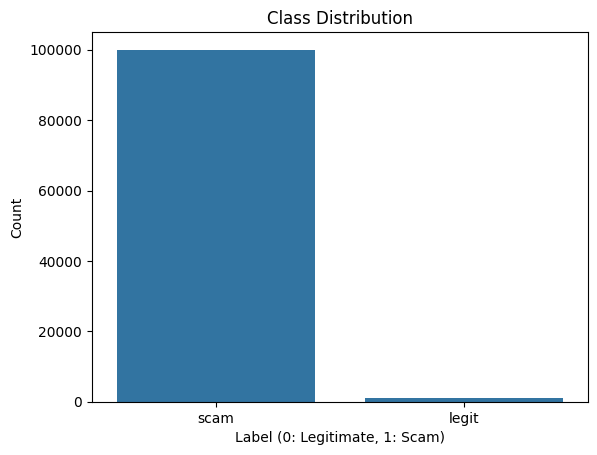

In [148]:
#  count the number of scam and legitimate links
class_distribution = datasets_df["label"].value_counts()

# plot the distribution
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title("Class Distribution")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Count")
plt.show()

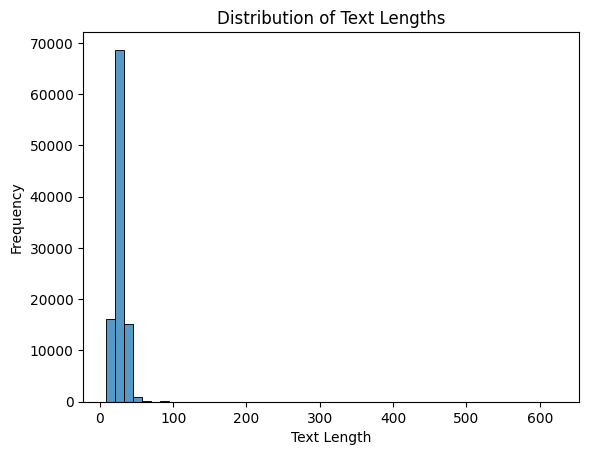

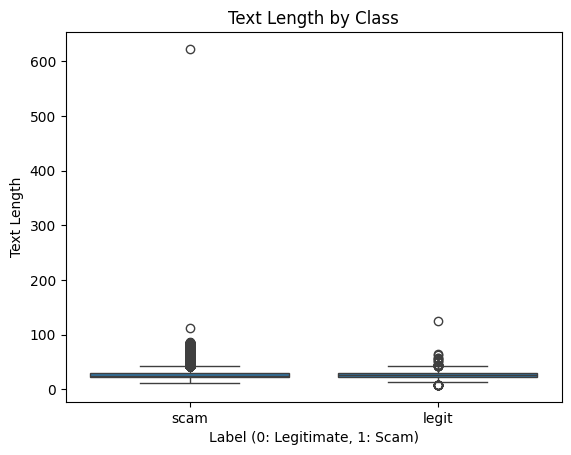

In [149]:
# add a column for text length
datasets_df["url_length"] = datasets_df["url"].apply(len)

# plot the distribution of text lengths
sns.histplot(datasets_df["url_length"], bins=50)
plt.title("Distribution of Text Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

# compare text lengths for scam vs. legitimate links
sns.boxplot(x="label", y="url_length", data=datasets_df)
plt.title("Text Length by Class")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Text Length")
plt.show()

Unique domains: 63744
Top TLDs: tld
com        28398
io          8732
dev         7538
xyz         7217
app         6738
net         6246
org         4221
top         2439
pro         1909
network     1749
Name: count, dtype: int64


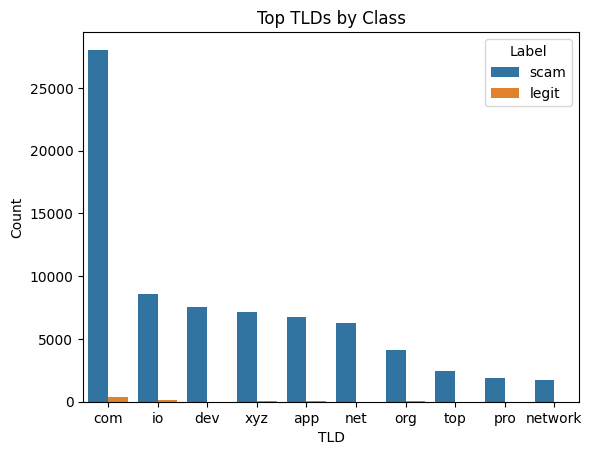

In [150]:
# extract domain and TLD
datasets_df["domain"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).domain)
datasets_df["tld"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).suffix)

# count unique domains and TLDs
print("Unique domains:", datasets_df["domain"].nunique())
print("Top TLDs:", datasets_df["tld"].value_counts().head(10))

# compare TLDs for scam vs. legitimate links
sns.countplot(x="tld", hue="label", data=datasets_df, order=datasets_df["tld"].value_counts().iloc[:10].index)
plt.title("Top TLDs by Class")
plt.xlabel("TLD")
plt.ylabel("Count")
plt.legend(title="Label", loc="upper right")
plt.show()

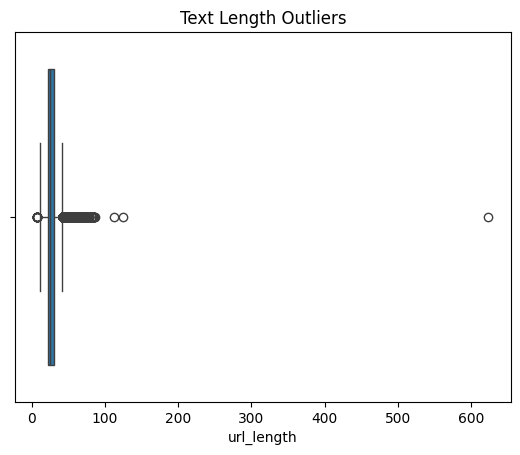

In [151]:
# boxplot for text length
sns.boxplot(x=datasets_df["url_length"])
plt.title("Text Length Outliers")
plt.show()

#### preprocessing

In [152]:
# function to process url
def procees_url(url):
    """Extracts features from a URL."""
    
    TECHNICAL_WORDS = {"www", "http", "https"}
                       
    SCAM_KEYWORDS = [
    "free", "giveaway", "bonus", "earn", "profit", "double", "investment", 
    "claim", "win", "lottery", "rich", "money", "wallet", "bitcoin", "crypto", 
    "ethereum", "blockchain", "binance", "support", "verification", "login", 
    "secure", "account", "recovery"
]
    
    # Convert to lowercase
    url = url.lower()
    
    # Extract domain, subdomain, and suffix
    extracted = tldextract.extract(url)
    # domain = extracted.domain
    subdomain = extracted.subdomain
    # tld = extracted.suffix
    
    # tokenisation (split URL into words based on delimiters)
    tokens = re.split(r"[-._~:/?#\[\]@!$&'()*+,;=]+", url)
    # remove only technical words
    filtered_tokens = [t for t in tokens if t and t not in TECHNICAL_WORDS]
    filtered_tokens = " ".join(filtered_tokens)
    
    # Count URL length and number of special characters
    url_length = len(url)
    special_char_count = len(re.findall(r'[.-_/]', url))
    
    # Common suspicious keywords
    keyword_count = sum(1 for token in tokens if token in SCAM_KEYWORDS)
    
    # Check for IP-based URLs (often used in phishing)
    # is_ip = bool(re.match(r'\b(?:[0-9]{1,3}\.){3}[0-9]{1,3}\b', url))

    return {
        # 'domain': domain,
        'subdomain': subdomain,
        # 'tld': tld,
        # 'url_length': url_length,
        'special_char_count': special_char_count,
        'keyword_count': keyword_count,
        # 'is_ip': is_ip,
        "tokenized_tokens": filtered_tokens
    }

# process the url
proceesed_df = pd.DataFrame([procees_url(url) for url in datasets_df["url"]])

In [153]:
proceesed_df

,subdomain,special_char_count,keyword_count,tokenized_tokens
0,,4,0,stakingpaalai cloud
1,coinomize-mix,5,0,coinomize mix pages dev
2,,4,1,claim kittytoken net
3,,4,0,nft liquity org
4,,4,0,dropshunter app
...,...,...,...,...
101189,register,5,0,register lootyfinances com
101190,indexrequestapp,5,0,indexrequestapp pages dev
101191,,4,0,nakapepes com
101192,,10,0,kyberswap com swap networkid 137


In [154]:
datasets_df[['subdomain','special_char_count','keyword_count', 'tokenized_tokens']] = proceesed_df[['subdomain','special_char_count','keyword_count', 'tokenized_tokens']] 

In [155]:
datasets_df

,name,url,label,label_no,url_length,domain,tld,subdomain,special_char_count,keyword_count,tokenized_tokens
0,stakingpaalai,https://stakingpaalai.cloud,scam,1,27,stakingpaalai,cloud,,4,0,stakingpaalai cloud
1,coinomize-mix,https://coinomize-mix.pages.dev,scam,1,31,pages,dev,coinomize-mix,5,0,coinomize mix pages dev
2,claim-kittytoken,https://claim-kittytoken.net,scam,1,28,claim-kittytoken,net,,4,1,claim kittytoken net
3,nft-liquity,https://nft-liquity.org,scam,1,23,nft-liquity,org,,4,0,nft liquity org
4,dropshunter,https://dropshunter.app,scam,1,23,dropshunter,app,,4,0,dropshunter app
...,...,...,...,...,...,...,...,...,...,...,...
101189,register,https://register.lootyfinances.com,scam,1,34,lootyfinances,com,register,5,0,register lootyfinances com
101190,indexrequestapp,https://indexrequestapp.pages.dev,scam,1,33,pages,dev,indexrequestapp,5,0,indexrequestapp pages dev
101191,nakapepes,https://nakapepes.com,scam,1,21,nakapepes,com,,4,0,nakapepes com
101192,Kyberswap Elastic (Polygon),https://kyberswap.com/swap?networkId=137,legit,0,40,kyberswap,com,,10,0,kyberswap com swap networkid 137
